In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)

from sklearn.metrics import (
    make_scorer,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [2]:
X_train = joblib.load("../data/processed/X_train.pkl")
y_train = joblib.load("../data/processed/y_train.pkl")

X_train_scaled = joblib.load("../data/processed/X_train_scaled.pkl")

In [3]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [4]:
scoring = {

    "accuracy":"accuracy",

    "precision":"precision",

    "recall":"recall",

    "f1":"f1",

    "roc":"roc_auc"

}

In [5]:
models = {

    "Logistic Regression":

        LogisticRegression(
            max_iter=1000,
            random_state=42
        ),

    "Decision Tree":

        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":

        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ),

    "XGBoost":

        XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        ),

    "LightGBM":

        LGBMClassifier(
            random_state=42
        ),

    "CatBoost":

        CatBoostClassifier(
            verbose=0,
            random_state=42
        )

}

In [6]:
cv_results = []

for name, model in models.items():

    print(f"Running {name}")

    if name == "Logistic Regression":

        scores = cross_validate(

            model,

            X_train_scaled,

            y_train,

            cv=cv,

            scoring=scoring,

            n_jobs=-1

        )

    else:

        scores = cross_validate(

            model,

            X_train,

            y_train,

            cv=cv,

            scoring=scoring,

            n_jobs=-1

        )

    cv_results.append({

        "Model":name,

        "Accuracy":

            scores["test_accuracy"].mean(),

        "Precision":

            scores["test_precision"].mean(),

        "Recall":

            scores["test_recall"].mean(),

        "F1":

            scores["test_f1"].mean(),

        "ROC":

            scores["test_roc"].mean()

    })

Running Logistic Regression
Running Decision Tree
Running Random Forest
Running XGBoost
Running LightGBM
Running CatBoost


In [7]:
cv_results = pd.DataFrame(cv_results)

cv_results.sort_values(
    by="F1",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC
3,XGBoost,0.999903,0.999738,0.999869,0.999803,0.999996
2,Random Forest,0.999903,0.999738,0.999869,0.999803,0.999978
5,CatBoost,0.999903,0.999738,0.999869,0.999803,0.999998
4,LightGBM,0.999774,0.999476,0.999606,0.999541,0.999958
0,Logistic Regression,0.999710,0.999083,0.999738,0.999410,0.999999
1,Decision Tree,0.999645,0.999344,0.999213,0.999278,0.999500


In [8]:
cv_results

,Model,Accuracy,Precision,Recall,F1,ROC
0,Logistic Regression,0.999710,0.999083,0.999738,0.999410,0.999999
1,Decision Tree,0.999645,0.999344,0.999213,0.999278,0.999500
2,Random Forest,0.999903,0.999738,0.999869,0.999803,0.999978
3,XGBoost,0.999903,0.999738,0.999869,0.999803,0.999996
4,LightGBM,0.999774,0.999476,0.999606,0.999541,0.999958
5,CatBoost,0.999903,0.999738,0.999869,0.999803,0.999998


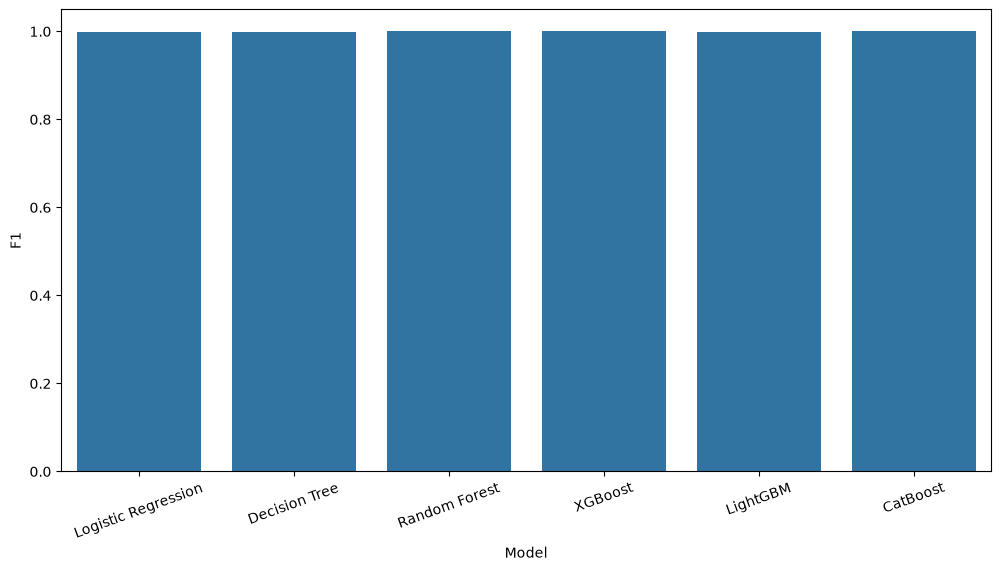

In [9]:
plt.figure(figsize=(12,6))

sns.barplot(

    data=cv_results,

    x="Model",

    y="F1"

)

plt.xticks(rotation=20)

plt.show()